In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
def get_data_loader(batch_size = 64):

    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
        ]
    )

    train_set = torchvision.datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
    test_set = torchvision.datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)

    #data loader
    train_loader = torch.utils.data.DataLoader(dataset=train_set, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(dataset=test_set, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


In [4]:
def imshow(img):

    img = img / 2 + 0.5  #[-1,1]  ---->>>>   [0,1]  
    np_img = img.numpy()
    plt.imshow(np.transpose(np_img, (1,2,0)))   #[a,b,c] ---->>>>  [b,c,a]

In [5]:
def get_sample_images(train_loader):

    data_iter = iter(train_loader)
    images, labels = next(data_iter)
    return images, labels

In [6]:
def visualize(n):

    train_loader, test_loader = get_data_loader()

    images, labels = get_sample_images(train_loader)
    plt.figure(figsize=(15, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        imshow(images[i])
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
    plt.show()

    

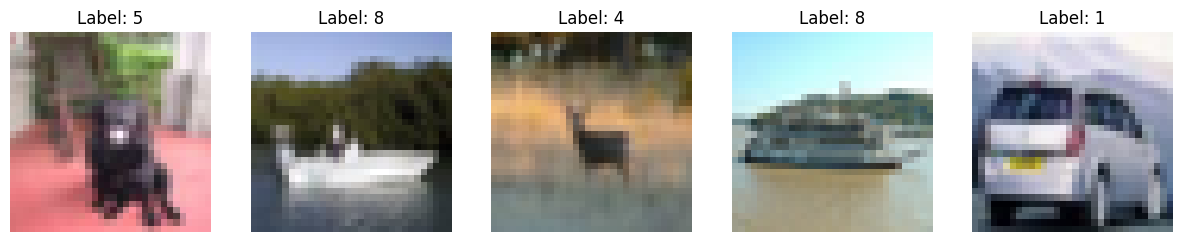

In [7]:
visualize(5)

In [8]:
train_loader, test_loader = get_data_loader()
images, labels = get_sample_images(train_loader)

In [9]:
images.shape

torch.Size([64, 3, 32, 32])

In [10]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1, stride=1)
        self.relu = nn.ReLU()
        self.pooling = nn.MaxPool2d(kernel_size=2, stride=2) ##Output = \frac{Input - Kernel}{Stride} + 1ü
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(0.2)

        # image 3x32x32 -> conv1 -> 32x32 -> relu -> 32x32 -> pooling -> 16x16 -> conv2 -> 16x16 -> pooling -> 8x8

        self.fc1 = nn.Linear(in_features= 64*8*8, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=10)


    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pooling(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pooling(x)

        x = x.view(-1, 64*8*8) #flatten

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x) #output layer

        return x 



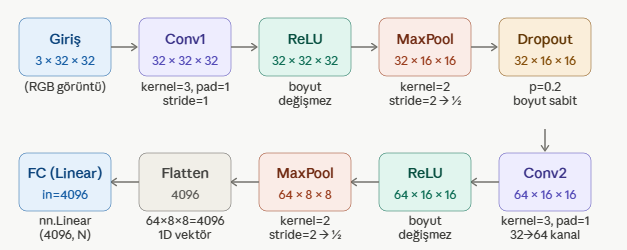

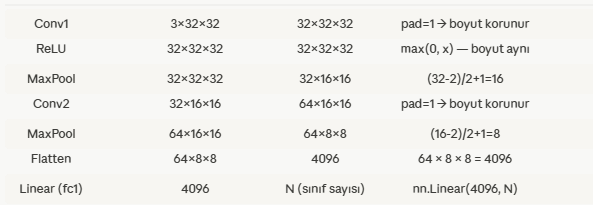

In [11]:
model=CNN().to(device=device)

In [12]:
define_loss_and_optimizer = lambda model: (
    nn.CrossEntropyLoss(),
    optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
)

In [13]:
def train_model(model, train_loader, criterion, optimizer, epochs = 5):

    model.train()
    train_losses = []

    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss = total_loss + loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1} / {epochs}, Loss: {avg_loss:.3f}")


    plt.figure()
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', linestyle="-", label="Train Loss")
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title('Train Loss')
    plt.legend()
    plt.show()

Epoch 1 / 16, Loss: 2.123
Epoch 2 / 16, Loss: 1.762
Epoch 3 / 16, Loss: 1.567
Epoch 4 / 16, Loss: 1.438
Epoch 5 / 16, Loss: 1.351
Epoch 6 / 16, Loss: 1.285
Epoch 7 / 16, Loss: 1.229
Epoch 8 / 16, Loss: 1.175
Epoch 9 / 16, Loss: 1.128
Epoch 10 / 16, Loss: 1.086
Epoch 11 / 16, Loss: 1.045
Epoch 12 / 16, Loss: 1.011
Epoch 13 / 16, Loss: 0.971
Epoch 14 / 16, Loss: 0.936
Epoch 15 / 16, Loss: 0.907
Epoch 16 / 16, Loss: 0.885


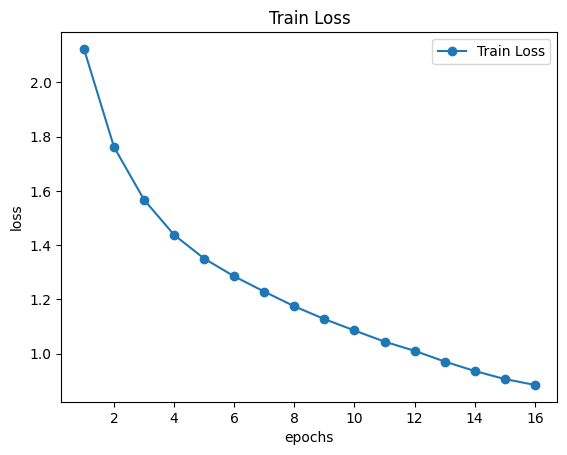

In [24]:
train_loader, test_loader = get_data_loader()
model=CNN().to(device=device)
criterion, optimizer = define_loss_and_optimizer(model)
train_model(model, train_loader, criterion, optimizer, epochs = 16)

In [ ]:
def test_model(model, test_loader, dataset_type):

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted==labels).sum().item()

    print(f"{dataset_type} Accuracy = {100*correct/total:.3f}%")


In [30]:
test_model(model, test_loader, dataset_type= "test")

test Accuracy = 67.580%


In [31]:
test_model(model, train_loader, dataset_type="train")

train Accuracy = 72.506%
